# 06 · Scorecard (Champion Model) — Versions A and B

**Pipeline:** time-proxy check → monotonic optimal binning → WOE → stepwise logistic regression → points scaling.
Fitting uses train (weeks 0–40); feature decisions use valid (41–50); OOT is left untouched until notebook 08.

| Version | Candidates | Priority |
|---|---|---|
| **A (standard)** | keeps features whose *distribution* drifted but whose *risk relationship* is stable | discrimination |
| **B (robust)** | additionally drops features with optimal-binning PSI > 0.25 | score stability |

Both versions share the same binning. Whether "drifting but stable" features should be kept is decided with OOT
evidence in notebook 08.

**WOE sign:** optbinning defines WOE = ln(%good / %bad), so larger WOE = safer and **all logistic coefficients must be
negative**. The sign check in the stepwise procedure uses this convention.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().resolve()
ROOT = ROOT.parent if ROOT.name == "notebooks" else ROOT
sys.path.insert(0, str(ROOT / "src"))

import gc
import json
import pickle
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
from optbinning import BinningProcess
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

from hcrisk.config import RES_DIR, SEED, TRAIN_END, VALID_END, savefig
from hcrisk.metrics import metrics

sel = pl.read_parquet(RES_DIR / "05_feature_selection.parquet")
GBDT_FEATS = list(dict.fromkeys(json.loads((RES_DIR / "05_gbdt_features.json").read_text())))
SC_CANDS = list(dict.fromkeys(json.loads((RES_DIR / "05_scorecard_candidates.json").read_text())))
DTYPE = dict(zip(sel["feature"], sel["dtype"]))
DATA = pl.scan_parquet(RES_DIR / "model_data.parquet")
print(f"GBDT pool {len(GBDT_FEATS)} | scorecard candidates {len(SC_CANDS)}")

GBDT pool 172 | scorecard candidates 93


## 1. Time-proxy check
A feature like "days since a campaign" grows linearly with application week when the campaign date is fixed — it
encodes *time*, not the customer. Spearman correlation with `WEEK_NUM` in the development sample; |ρ| > 0.5 is
removed from **both** pools. The updated GBDT pool is saved for notebook 07.

In [2]:
pool = sorted(set(GBDT_FEATS) | set(SC_CANDS))
num_pool = [f for f in pool if DTYPE[f] != "String"]
samp = DATA.filter(pl.col("WEEK_NUM") <= VALID_END).select(["WEEK_NUM"] + num_pool).collect()
r = samp.sample(n=min(200_000, samp.height), seed=11).with_columns(pl.col(pl.Boolean).cast(pl.Float32)).to_pandas().astype("float64").rank()
rho = r[num_pool].corrwith(r["WEEK_NUM"])
del samp, r; _ = gc.collect()

tp = pl.DataFrame({"feature": rho.index.tolist(), "rho_week": rho.values}).with_columns(
    pl.col("rho_week").abs().alias("abs_rho")).sort("abs_rho", descending=True)
TIME_PROXY = tp.filter(pl.col("abs_rho") > 0.5)["feature"].to_list()
print(f"time proxies (|rho| > 0.5) removed: {TIME_PROXY}")
display(tp.filter(pl.col("abs_rho") > 0.3).join(sel.select("feature", "table", "iv_train"), on="feature", how="left"))
GBDT_FEATS = [f for f in GBDT_FEATS if f not in TIME_PROXY]
SC_CANDS = [f for f in SC_CANDS if f not in TIME_PROXY]
(RES_DIR / "06_gbdt_features.json").write_text(json.dumps(GBDT_FEATS, indent=1))
tp.write_parquet(RES_DIR / "06_time_proxy_check.parquet")
print(f"GBDT pool -> {len(GBDT_FEATS)} (saved for notebook 07) | scorecard candidates -> {len(SC_CANDS)}")

time proxies (|rho| > 0.5) removed: ['collaterals_typeofguarante_359M__nuniq', 'purposeofcred_874M__nuniq', 'classificationofcontr_400M__nuniq']


feature,rho_week,abs_rho,table,iv_train
str,f64,f64,str,f64
"""collaterals_typeofguarante_359…",0.541876,0.541876,"""credit_bureau_a_2""",0.038777
"""purposeofcred_874M__nuniq""",0.539209,0.539209,"""credit_bureau_a_1""",0.023475
"""classificationofcontr_400M__nu…",0.538107,0.538107,"""credit_bureau_a_1""",0.023046
"""credit_bureau_a_2__cnt""",0.375433,0.375433,"""credit_bureau_a_2""",0.029206


GBDT pool -> 169 (saved for notebook 07) | scorecard candidates -> 92


## 2. Development sample

In [3]:
d = (DATA.filter(pl.col("WEEK_NUM") <= VALID_END).select(["WEEK_NUM", "target"] + SC_CANDS).collect()
         .with_columns(pl.col(pl.Boolean).cast(pl.Float32)))
is_tr = (d["WEEK_NUM"] <= TRAIN_END).to_numpy()
wk_dev, y_all = d["WEEK_NUM"].to_numpy(), d["target"].to_numpy()
X_all = d.drop("WEEK_NUM", "target").to_pandas()
del d; _ = gc.collect()
CAT = [f for f in SC_CANDS if DTYPE[f] == "String"]
for c in CAT:
    X_all[c] = X_all[c].astype(object)
X_tr, X_va, y_tr, y_va = X_all[is_tr], X_all[~is_tr], y_all[is_tr], y_all[~is_tr]
print(f"train {len(X_tr):,} rows (bad rate {y_tr.mean():.2%}) | valid {len(X_va):,} rows (bad rate {y_va.mean():.2%})")

train 778,703 rows (bad rate 2.90%) | valid 251,298 rows (bad rate 3.68%)


## 3. Optimal binning and WOE (shared by A and B)
Up to 20 pre-bins merged by the optimiser; each bin ≥ 5% of train; numeric features forced monotonic
(ascending or descending chosen automatically); missing values get their own bin. Kept: IV ≥ 0.02 with ≥ 2 bins.

In [4]:
t0 = time.time()
bp = BinningProcess(SC_CANDS, categorical_variables=CAT, max_n_prebins=20, min_bin_size=0.05,
                    binning_fit_params={f: {"monotonic_trend": "auto_asc_desc"} for f in SC_CANDS if f not in CAT})
bp.fit(X_tr, y_tr)
print(f"optimal binning done in {time.time() - t0:.0f}s")
W_tr = bp.transform(X_tr, metric="woe", metric_missing="empirical", metric_special="empirical")
W_va = bp.transform(X_va, metric="woe", metric_missing="empirical", metric_special="empirical")


def iv_psi_from_woe(w_tr, y1, w_va, y2):
    """Bins are identified by their WOE value; returns (valid IV, train-vs-valid PSI) on the optimal bins."""
    a = pd.DataFrame({"b": w_tr, "y": y1}).groupby("b")["y"].agg(["count", "sum"])
    b = pd.DataFrame({"b": w_va, "y": y2}).groupby("b")["y"].agg(["count", "sum"])
    t = a.join(b, lsuffix="_tr", rsuffix="_va", how="outer").fillna(0) + 0.5
    s_tr, s_va = t["count_tr"] / t["count_tr"].sum(), t["count_va"] / t["count_va"].sum()
    bad, good = t["sum_va"] / t["sum_va"].sum(), (t["count_va"] - t["sum_va"]) / (t["count_va"] - t["sum_va"]).sum()
    return float(((bad - good) * np.log(bad / good)).sum()), float(((s_va - s_tr) * np.log(s_va / s_tr)).sum())


summ = pl.from_pandas(bp.summary()[["name", "dtype", "n_bins", "iv", "gini"]]).rename({"name": "feature", "iv": "iv_opt"})
summ = summ.join(pl.DataFrame([dict(zip(["feature", "iv_opt_valid", "psi_opt"],
                                        [f, *iv_psi_from_woe(W_tr[f].values, y_tr, W_va[f].values, y_va)])) for f in SC_CANDS]),
                 on="feature").sort("iv_opt", descending=True)
ELIGIBLE = summ.filter((pl.col("iv_opt") >= 0.02) & (pl.col("n_bins") >= 2))["feature"].to_list()
print(f"eligible after optimal binning: {len(ELIGIBLE)} / {len(SC_CANDS)}")
display(summ.head(30))

optimal binning done in 30s


eligible after optimal binning: 82 / 92


feature,dtype,n_bins,iv_opt,gini,iv_opt_valid,psi_opt
str,str,i64,f64,f64,f64,f64
"""avgdpdtolclosure24_3658938P""","""numerical""",4,0.306263,0.281184,0.320436,0.000356
"""pmts_dpd_1073P__mean""","""numerical""",4,0.283802,0.268258,0.278429,0.018881
"""pctinstlsallpaidlate1d_3546856…","""numerical""",7,0.270758,0.27681,0.294148,0.000277
"""maxdpdtolerance_577P__mean""","""numerical""",5,0.265542,0.256077,0.300483,0.000549
"""maxdbddpdtollast12m_3658940P""","""numerical""",6,0.243436,0.238008,0.264513,0.001542
…,…,…,…,…,…,…
"""maxdbddpdlast1m_3658939P""","""numerical""",5,0.100314,0.13232,0.095673,0.002562
"""mobilephncnt_593L""","""numerical""",4,0.095494,0.162146,0.106235,0.000065
"""employedfrom_700D__max""","""numerical""",9,0.093823,0.164745,0.08408,0.010716


## 4. Candidate pools for A and B
`education_1103M` is excluded from both: it duplicates `education_927M`, and its category codes change in the
validation period (unseen codes) in the full data.

In [5]:
EXCLUDE = ["education_1103M"]
PSI_MAX_B = 0.25
psi_map = dict(zip(summ["feature"], summ["psi_opt"]))
ELIG_A = [f for f in ELIGIBLE if f not in EXCLUDE]
ELIG_B = [f for f in ELIG_A if psi_map[f] <= PSI_MAX_B]
print(f"A candidates: {len(ELIG_A)} | B candidates: {len(ELIG_B)} (removed {len(ELIG_A) - len(ELIG_B)} with PSI > {PSI_MAX_B})")
display(summ.filter(pl.col("feature").is_in([f for f in ELIG_A if f not in ELIG_B])).select("feature", "iv_opt", "iv_opt_valid", "psi_opt"))

A candidates: 81 | B candidates: 70 (removed 11 with PSI > 0.25)


feature,iv_opt,iv_opt_valid,psi_opt
str,f64,f64,f64
"""dpdmaxdateyear_596T_yrsago__me…",0.232851,0.177956,0.410385
"""pmts_overdue_1152A__mean""",0.216893,0.335298,0.6176
"""numberofoverdueinstlmaxdat_148…",0.119484,0.232212,0.26273
"""dpdmaxdateyear_896T_yrsago__me…",0.07367,0.116462,0.619764
"""totalamount_6A__mean""",0.055977,0.088544,0.555371
…,…,…,…
"""collaterals_typeofguarante_359…",0.037334,0.052573,0.576556
"""collater_valueofguarantee_876L…",0.035899,0.048815,0.620423
"""nominalrate_498L__mean""",0.029136,0.057118,0.332714


## 5. Stepwise selection and scorecard construction
**Forward:** try candidates by descending IV; accept only if (1) WOE correlation with selected features ≤ 0.7,
(2) all coefficients negative, (3) max VIF ≤ 5, (4) valid AUC improves by ≥ 0.001. At most 25 features.
**Backward:** drop any feature whose removal costs < 0.0005 valid AUC.

**Scaling:** 600 points at good:bad odds of 50:1, PDO = 20 (odds double every 20 points); higher = safer.

In [6]:
MAX_FEATS, MIN_GAIN, VIF_MAX, CORR_MAX = 25, 0.001, 5.0, 0.7
Wv = W_tr.iloc[np.random.default_rng(0).choice(len(W_tr), size=min(200_000, len(W_tr)), replace=False)]


def fit_lr(cols):
    return LogisticRegression(C=1.0, max_iter=1000).fit(W_tr[cols].values, y_tr)


def vif_list(cols):
    A = Wv[cols].values
    out = []
    for j in range(len(cols)):
        others = np.column_stack([np.ones(len(A)), np.delete(A, j, axis=1)])
        beta, *_ = np.linalg.lstsq(others, A[:, j], rcond=None)
        r2 = 1 - (A[:, j] - others @ beta).var() / A[:, j].var()
        out.append(1 / max(1 - r2, 1e-9))
    return out


def stepwise(eligible):
    selected, best_auc, log = [], 0.5, []
    for f in eligible:
        if len(selected) >= MAX_FEATS:
            break
        cmax = max((abs(np.corrcoef(Wv[f], Wv[s])[0, 1]) for s in selected), default=0.0)
        if cmax > CORR_MAX:
            log.append({"feature": f, "decision": "skip", "reason": f"WOE correlation {cmax:.2f}"}); continue
        cols = selected + [f]
        m = fit_lr(cols)
        if (m.coef_[0] >= 0).any():
            log.append({"feature": f, "decision": "skip", "reason": "wrong coefficient sign"}); continue
        v = max(vif_list(cols)) if len(cols) > 1 else 1.0
        if v > VIF_MAX:
            log.append({"feature": f, "decision": "skip", "reason": f"VIF {v:.1f}"}); continue
        auc_va = roc_auc_score(y_va, m.predict_proba(W_va[cols].values)[:, 1])
        if auc_va - best_auc < MIN_GAIN:
            log.append({"feature": f, "decision": "skip", "reason": f"valid AUC gain {auc_va - best_auc:+.4f}"}); continue
        selected.append(f); best_auc = auc_va
        log.append({"feature": f, "decision": "add", "reason": f"valid AUC {auc_va:.4f}"})
        print(f"  +{len(selected):>2}  {f:45s} valid AUC {auc_va:.4f}")
    while len(selected) > 1:
        drops = []
        for f in selected:
            cols = [x for x in selected if x != f]
            drops.append((best_auc - roc_auc_score(y_va, fit_lr(cols).predict_proba(W_va[cols].values)[:, 1]), f))
        loss, f = min(drops)
        if loss >= 0.0005:
            break
        selected.remove(f); best_auc -= loss
        log.append({"feature": f, "decision": "backward drop", "reason": f"AUC loss {loss:.4f}"})
        print(f"  -    {f:45s} backward drop (AUC loss {loss:.4f})")
    print(f"final: {len(selected)} features, valid AUC {best_auc:.4f}")
    return selected, pl.DataFrame(log, infer_schema_length=None)


PDO, BASE_SCORE, BASE_ODDS = 20, 600, 50
factor = PDO / np.log(2)
offset = BASE_SCORE - factor * np.log(BASE_ODDS)


def build_scorecard(selected, tag):
    lr = fit_lr(selected)
    coef = (pl.DataFrame({"feature": selected, "coef": lr.coef_[0], "vif": np.round(vif_list(selected), 2)})
              .join(summ.select("feature", "dtype", "n_bins", "iv_opt", "iv_opt_valid", "psi_opt"), on="feature")
              .join(sel.select("feature", "table"), on="feature", how="left").sort("iv_opt", descending=True))
    base_points = round(offset - factor * lr.intercept_[0])
    rows = []
    for f, b in zip(selected, lr.coef_[0]):
        bt = bp.get_binned_variable(f).binning_table.build().drop(index="Totals", errors="ignore")
        for _, r in bt.iterrows():
            if r["Count"] == 0:
                continue
            lab = r["Bin"]
            if not isinstance(lab, str) and hasattr(lab, "__len__"):
                lab = "{" + ", ".join(map(str, list(lab))) + "}"
            rows.append({"feature": f, "bin": str(lab), "count_pct": round(r["Count (%)"], 4),
                         "bad_rate": round(r["Event rate"], 4), "woe": round(r["WoE"], 4),
                         "points": int(round(-factor * b * r["WoE"]))})
    card = pl.DataFrame(rows)

    def score(W):
        return base_points + sum(np.round(-factor * b * W[f].values) for f, b in zip(selected, lr.coef_[0]))
    s_tr, s_va = score(W_tr), score(W_va)

    edges = np.unique(np.quantile(s_tr, np.linspace(0, 1, 11)[1:-1]))
    band = lambda s, y: pd.DataFrame({"band": np.searchsorted(edges, s, side="right"), "y": y}).groupby("band")["y"].agg(["count", "mean"])
    bands = band(s_tr, y_tr).join(band(s_va, y_va), lsuffix="_train", rsuffix="_valid").fillna(0)
    bands["share_train"] = bands["count_train"] / bands["count_train"].sum()
    bands["share_valid"] = bands["count_valid"] / bands["count_valid"].sum()
    score_psi = float(((bands["share_valid"] - bands["share_train"]) *
                       np.log((bands["share_valid"] + 1e-6) / (bands["share_train"] + 1e-6))).sum())
    lo, hi = [-np.inf] + list(edges), list(edges) + [np.inf]
    bands.insert(0, "score_range", [f"[{lo[i]:.0f}, {hi[i]:.0f})" for i in bands.index])
    bands["valid/train bad rate"] = bands["mean_valid"] / bands["mean_train"]

    s_all = np.empty(len(y_all)); s_all[is_tr], s_all[~is_tr] = s_tr, s_va
    weekly = pd.DataFrame({"w": wk_dev, "y": y_all, "s": s_all}).groupby("w").apply(
        lambda t: 2 * roc_auc_score(t["y"], -t["s"]) - 1, include_groups=False)
    m_tr, m_va = metrics(y_tr, -s_tr), metrics(y_va, -s_va)
    print(f"[{tag}] {len(selected)} features | base points {base_points} | train AUC {m_tr['AUC']} KS {m_tr['KS']} | "
          f"valid AUC {m_va['AUC']} KS {m_va['KS']} | score PSI {score_psi:.4f}")
    display(coef)
    display(bands[["score_range", "share_train", "mean_train", "share_valid", "mean_valid", "valid/train bad rate"]].round(4))
    model = {"variant": tag, "features": selected, "coef": lr.coef_[0].tolist(), "intercept": float(lr.intercept_[0]),
             "categorical": [f for f in selected if f in CAT],
             "scaling": {"PDO": PDO, "BASE_SCORE": BASE_SCORE, "BASE_ODDS": BASE_ODDS, "factor": factor,
                         "offset": offset, "base_points": base_points}}
    (RES_DIR / f"06_scorecard_model_{tag}.json").write_text(json.dumps(model, indent=1))
    card.write_csv(RES_DIR / f"06_scorecard_table_{tag}.csv", include_bom=True)
    coef.write_csv(RES_DIR / f"06_scorecard_features_{tag}.csv", include_bom=True)
    return {"tag": tag, "n": len(selected), "train": m_tr, "valid": m_va, "score_psi": score_psi,
            "bands": bands, "weekly": weekly}

## 6. Version A (standard)

In [7]:
selA, logA = stepwise(ELIG_A)
logA.write_csv(RES_DIR / "06_stepwise_log_A.csv", include_bom=True)
resA = build_scorecard(selA, "A")

  + 1  avgdpdtolclosure24_3658938P                   valid AUC 0.6406


  + 2  pmts_dpd_1073P__mean                          valid AUC 0.6814


  + 3  maxdpdtolerance_577P__mean                    valid AUC 0.6898


  + 4  dpdmaxdateyear_596T_yrsago__mean              valid AUC 0.7084


  + 5  avgdbddpdlast24m_3658932P                     valid AUC 0.7100


...

  -    empl_employedfrom_271D__max                   backward drop (AUC loss 0.0002)


final: 18 features, valid AUC 0.7893


[A] 18 features | base points 589 | train AUC 0.7881 KS 0.4394 | valid AUC 0.7888 KS 0.4365 | score PSI 0.0343


feature,coef,vif,dtype,n_bins,iv_opt,iv_opt_valid,psi_opt,table
str,f64,f64,str,i64,f64,f64,f64,str
"""avgdpdtolclosure24_3658938P""",-0.382031,1.9,"""numerical""",4,0.306263,0.320436,0.000356,"""depth0"""
"""pmts_dpd_1073P__mean""",-0.503965,1.77,"""numerical""",4,0.283802,0.278429,0.018881,"""credit_bureau_a_2"""
"""maxdpdtolerance_577P__mean""",-0.221891,1.86,"""numerical""",5,0.265542,0.300483,0.000549,"""applprev_1"""
"""dpdmaxdateyear_596T_yrsago__me…",-0.56758,1.15,"""numerical""",8,0.232851,0.177956,0.410385,"""credit_bureau_a_1"""
"""pmts_overdue_1152A__mean""",-0.440914,1.16,"""numerical""",5,0.216893,0.335298,0.6176,"""credit_bureau_a_2"""
…,…,…,…,…,…,…,…,…
"""pmtnum_8L__mean""",-0.639856,1.34,"""numerical""",9,0.075292,0.10806,0.001454,"""applprev_1"""
"""dpdmaxdateyear_896T_yrsago__me…",-0.258308,1.43,"""numerical""",6,0.07367,0.116462,0.619764,"""credit_bureau_a_1"""
"""totalamount_6A__mean""",-0.441149,1.21,"""numerical""",6,0.055977,0.088544,0.555371,"""credit_bureau_a_1"""


,score_range,share_train,mean_train,share_valid,mean_valid,valid/train bad rate
band,,,,,,
0,"[-inf, 565)",0.0999,0.1133,0.0972,0.1435,1.2667
1,"[565, 579)",0.0925,0.0594,0.0781,0.0813,1.3691
2,"[579, 588)",0.0990,0.0396,0.0798,0.0530,1.3399
3,"[588, 597)",0.1053,0.0265,0.0875,0.0402,1.5171
4,"[597, 605)",0.0926,0.0191,0.0847,0.0300,1.5668
5,"[605, 613)",0.1088,0.0129,0.0962,0.0214,1.6589
6,"[613, 621)",0.0958,0.0097,0.0940,0.0161,1.6577
7,"[621, 631)",0.1007,0.0063,0.1100,0.0108,1.7041
8,"[631, 644)",0.1007,0.0043,0.1207,0.0074,1.7239


## 7. Version B (robust, PSI ≤ 0.25)

In [8]:
selB, logB = stepwise(ELIG_B)
logB.write_csv(RES_DIR / "06_stepwise_log_B.csv", include_bom=True)
resB = build_scorecard(selB, "B")

  + 1  avgdpdtolclosure24_3658938P                   valid AUC 0.6406


  + 2  pmts_dpd_1073P__mean                          valid AUC 0.6814


  + 3  maxdpdtolerance_577P__mean                    valid AUC 0.6898


  + 4  avgdbddpdlast24m_3658932P                     valid AUC 0.6925


  + 5  numberofoverdueinstlmaxdat_641D__max          valid AUC 0.6954


...

  -    instlamount_768A__mean                        backward drop (AUC loss 0.0002)


final: 17 features, valid AUC 0.7815


[B] 17 features | base points 589 | train AUC 0.7864 KS 0.4359 | valid AUC 0.7819 KS 0.4238 | score PSI 0.0091


feature,coef,vif,dtype,n_bins,iv_opt,iv_opt_valid,psi_opt,table
str,f64,f64,str,i64,f64,f64,f64,str
"""avgdpdtolclosure24_3658938P""",-0.431012,1.89,"""numerical""",4,0.306263,0.320436,0.000356,"""depth0"""
"""pmts_dpd_1073P__mean""",-0.627543,1.72,"""numerical""",4,0.283802,0.278429,0.018881,"""credit_bureau_a_2"""
"""maxdpdtolerance_577P__mean""",-0.257005,1.87,"""numerical""",5,0.265542,0.300483,0.000549,"""applprev_1"""
"""numberofoverdueinstlmaxdat_641…",-0.301868,1.79,"""numerical""",5,0.168605,0.189674,0.002105,"""credit_bureau_a_1"""
"""lastrejectdate_50D""",-0.317345,1.4,"""numerical""",7,0.161431,0.205215,0.00288,"""depth0"""
…,…,…,…,…,…,…,…,…
"""empl_employedfrom_271D__max""",-0.657083,1.18,"""numerical""",6,0.072575,0.044258,0.01023,"""person_1"""
"""totalamount_996A__mean""",-0.431887,1.19,"""numerical""",7,0.064587,0.073753,0.005086,"""credit_bureau_a_1"""
"""dateofcredstart_739D__min""",-1.264988,1.09,"""numerical""",8,0.046172,0.04513,0.026832,"""credit_bureau_a_1"""


,score_range,share_train,mean_train,share_valid,mean_valid,valid/train bad rate
band,,,,,,
0,"[-inf, 564)",0.0964,0.1122,0.0871,0.1462,1.3023
1,"[564, 578)",0.0970,0.0622,0.0847,0.0790,1.2707
2,"[578, 588)",0.1030,0.0384,0.0923,0.0543,1.4144
3,"[588, 596)",0.0945,0.0265,0.0880,0.0397,1.5000
4,"[596, 604)",0.0996,0.0197,0.0972,0.0299,1.5168
5,"[604, 611)",0.0884,0.0132,0.0910,0.0200,1.5136
6,"[611, 619)",0.1095,0.0098,0.1103,0.0152,1.5526
7,"[619, 628)",0.1054,0.0068,0.1137,0.0108,1.5908
8,"[628, 640)",0.1062,0.0045,0.1186,0.0071,1.5791


## 8. A vs B on the development sample
- `score_PSI`: score-distribution drift train → valid
- `top_band_share_change`: change in the share of the safest decile (positive = scores inflating)
- `avg_valid/train_bad_rate`: bad-rate ratio within the same score band (calibration drift)

In the full data, both versions show a valid/train bad-rate ratio of ~1.45: most of the calibration gap comes from the
genuine rise in risk, not from feature drift — so the score-to-PD mapping must be refreshed in production regardless.

version,n_features,AUC_train,AUC_valid,KS_valid,score_PSI,top_band_share_change,avg_valid/train_bad_rate,weekly_gini_std
str,i64,f64,f64,f64,f64,f64,f64,f64
"""A""",18,0.7881,0.7888,0.4365,0.0343,0.0472,1.516,0.0366
"""B""",17,0.7864,0.7819,0.4238,0.0091,0.0172,1.445,0.0279


shared features: 13 | A only: ['dpdmaxdateyear_596T_yrsago__mean', 'pmts_overdue_1152A__mean', 'numberofoverdueinstlmaxdat_148D__max', 'dpdmaxdateyear_896T_yrsago__mean', 'totalamount_6A__mean'] | B only: ['maxdpdlast6m_474P', 'empl_employedfrom_271D__max', 'totalamount_996A__mean', 'dateofcredstart_739D__min']


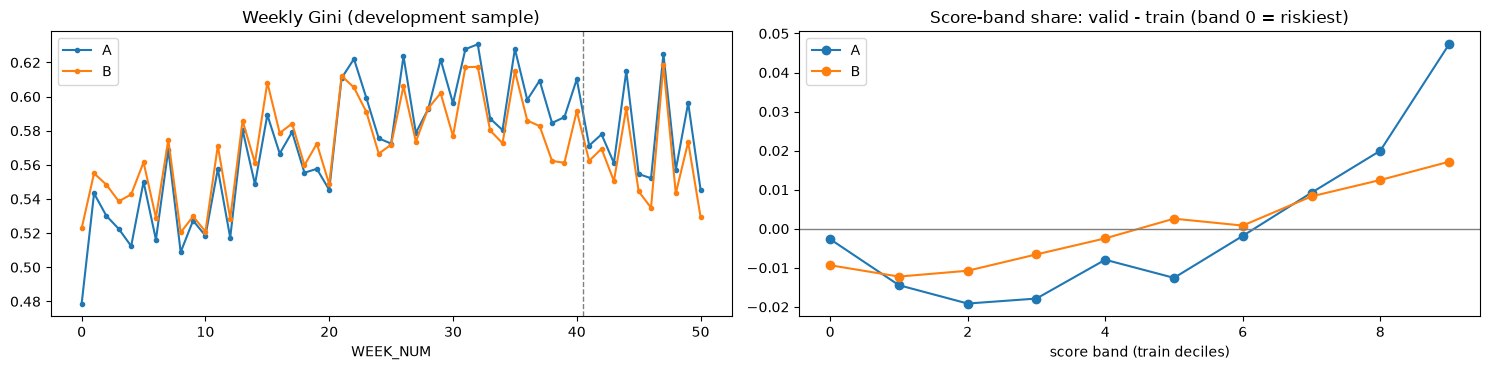

saved: 06_binning_process.pkl, 06_scorecard_model_{A,B}.json, 06_scorecard_table_{A,B}.csv, 06_gbdt_features.json


In [9]:
cmp = pl.DataFrame([{
    "version": r["tag"], "n_features": r["n"], "AUC_train": r["train"]["AUC"], "AUC_valid": r["valid"]["AUC"],
    "KS_valid": r["valid"]["KS"], "score_PSI": round(r["score_psi"], 4),
    "top_band_share_change": round(float(r["bands"]["share_valid"].iloc[-1] - r["bands"]["share_train"].iloc[-1]), 4),
    "avg_valid/train_bad_rate": round(float(r["bands"]["valid/train bad rate"].mean()), 3),
    "weekly_gini_std": round(float(r["weekly"].std()), 4)} for r in (resA, resB)])
display(cmp)
print(f"shared features: {len(set(selA) & set(selB))} | A only: {[f for f in selA if f not in selB]} | B only: {[f for f in selB if f not in selA]}")

fig, axes = plt.subplots(1, 2, figsize=(15, 3.8))
for r, col in ((resA, "C0"), (resB, "C1")):
    axes[0].plot(r["weekly"].index, r["weekly"].values, marker="o", ms=3, color=col, label=r["tag"])
    b = r["bands"]
    axes[1].plot(range(len(b)), b["share_valid"] - b["share_train"], marker="o", color=col, label=r["tag"])
axes[0].axvline(TRAIN_END + 0.5, color="grey", ls="--", lw=1); axes[0].set_title("Weekly Gini (development sample)")
axes[0].set_xlabel("WEEK_NUM"); axes[0].legend()
axes[1].axhline(0, color="grey", lw=1); axes[1].set_title("Score-band share: valid - train (band 0 = riskiest)")
axes[1].set_xlabel("score band (train deciles)"); axes[1].legend()
plt.tight_layout(); savefig(fig, "06_scorecard_A_vs_B"); plt.show()

with open(RES_DIR / "06_binning_process.pkl", "wb") as fh:
    pickle.dump(bp, fh)
summ.write_csv(RES_DIR / "06_optbin_summary.csv", include_bom=True)
cmp.write_csv(RES_DIR / "06_variant_comparison.csv", include_bom=True)
print("saved: 06_binning_process.pkl, 06_scorecard_model_{A,B}.json, 06_scorecard_table_{A,B}.csv, 06_gbdt_features.json")